In [17]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

from src import config

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
test = {"a": [1, 2], "b": [1, 2, 3]}
import numpy as np

np.prod([len(v) for v in test.values()])

np.int64(6)

In [18]:
DATE_COLS = ["date"]
NUMERIC_COLS = ["year", "depth (m)", "total"]


def load_reef_check_data(path: str) -> pd.DataFrame:
    """Load and process Reef Check substrate data"""
    df = pd.read_csv(
        path,
        parse_dates=DATE_COLS,
        date_format=lambda x: pd.to_datetime(x, format="%Y-%m-%d", errors="coerce"),
        low_memory=False,
    )

    # coerce columns to numeric. 'coerce' sets bad values to nan
    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["depth (m)"] = pd.to_numeric(df["depth (m)"], errors="coerce").astype("Float64")
    df["total"] = pd.to_numeric(df["total"], errors="coerce").astype("Int64")
    df["date"] = pd.to_datetime(df["date"], format="%d-%B-%y", errors="coerce")

    # split 'coordinates_in_decimal_degree_format' into 'latitude' and 'longitude'
    latlon_cols = df["coordinates_in_decimal_degree_format"].str.split(",", expand=True)
    latlon_cols = latlon_cols.apply(pd.to_numeric, errors="coerce")
    latlon_cols.columns = ["latitude", "longitude"]
    df[["latitude", "longitude"]] = latlon_cols

    return df


df = load_reef_check_data(
    "/Users/rt582/Downloads/Reef Check Data- WW site subs 021126/Substrate.csv"
)

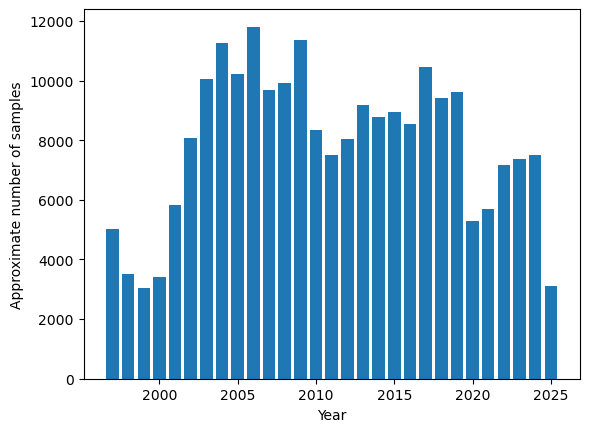

In [19]:
years = df.year.value_counts().sort_index()
plt.bar(years.index, years.values / 4)
plt.xlabel("Year")
plt.ylabel("Approximate number of samples")
plt.show()

In [20]:
def summarise_errors(df: pd.DataFrame, errors_csv_fp: str | Path) -> pd.DataFrame:
    """Filter rows with marked errors e.g. incomplete substrate"""

    # proportion of data with errors of some kind
    print(
        f"{100 * len(df[df['errors'] == True]) / len(df):.02f}% of rows contain errors"
    )
    # select errors corresponding to substrate
    error_info = df[
        df["what_errors"].notna()
        & (
            df["what_errors"].str.contains("substrate")
            | df["what_errors"].str.contains(r"S[1-4]", regex=True)
        )
    ].what_errors.value_counts()

    if not Path(errors_csv_fp).exists():
        # save error info to csv
        error_info.to_csv(errors_csv_fp)
        print(f"Now go and manually filter errors in {errors_csv_fp}")
    else:
        print(f"Error summary already exists at {errors_csv_fp}")


def remove_errors(
    df: pd.DataFrame, completed_errors_csv_fp: str | Path
) -> pd.DataFrame:
    """Remove rows with marked errors using csv with "S*" 0/1 columns

    Args:
        df (pd.DataFrame): Reef Check substrate data
        completed_errors_csv_fp (str | Path): Path to csv with "S*" 0/1 columns

    Returns:
        pd.DataFrame
    """
    # remove any rows where 'total' is nan
    df = df[df["total"].notna()]
    error_info_complete = pd.read_csv(completed_errors_csv_fp)
    seg_cols = [c for c in ["S1", "S2", "S3", "S4"] if c in error_info_complete.columns]

    drop_rules = (
        error_info_complete.assign(
            what_errors=lambda d: d["what_errors"].fillna("").str.strip().str.lower(),
            **{
                c: pd.to_numeric(error_info_complete[c], errors="coerce")
                .fillna(0)
                .astype(int)
                for c in seg_cols
            },  # ensure full and integers
        )
        .melt(
            id_vars="what_errors",
            value_vars=seg_cols,
            var_name="segment_code",
            value_name="keep",
        )  # melt into long format
        .query("keep == 0")[["what_errors", "segment_code"]]
        .drop_duplicates()
    )

    df.loc[:, "what_errors"] = df["what_errors"].fillna("").str.strip().str.lower()
    df.loc[:, "segment_code"] = (
        df["segment_code"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
        .str.replace(r"^SEGMENT\s*", "", regex=True)
        .str.replace(r"^S\s*", "S", regex=True)
        .str.replace(r"^(\d)$", r"S\1", regex=True)
    )  # ensure consistency in segment_code field

    n0 = len(df)
    df = df.merge(
        drop_rules.assign(_drop=True), on=["what_errors", "segment_code"], how="left"
    )
    df = df[df["_drop"].isna()].drop(columns="_drop")
    print(
        f"Dropped {n0 - len(df):,}; kept {len(df):,}/{n0:,} ({100 * len(df) / n0:.2f}%)."
    )
    return df


summarise_errors(df, config.sully_og_dir / "reefcheck_error_info.csv")
processed_df = remove_errors(
    df, config.sully_og_dir / "reefcheck_error_info_completed.csv"
)

21.09% of rows contain errors
Error summary already exists at /Users/rt582/Library/CloudStorage/OneDrive-UniversityofCambridge/cambridge/phd/Paper_Conferences/reef_cover_economics/data/sully_og/reefcheck_error_info.csv
Dropped 11,921; kept 898,560/910,481 (98.69%).


In [21]:
def filter_substrate_total_errors(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove all rows belonging to any (survey_id, segment_code) group
    where the sum of 'total' is not 40. Works safely for any length of df.
    """
    # Ensure 'total' is numeric for correct groupby aggregation
    df = df.copy()
    gb = df.groupby(["survey_id", "segment_code"])["total"].sum()
    # Identify all (survey_id, segment_code) tuples where sum != 40
    bad_keys = set(gb.index[gb != 40])
    # Mask: True for good rows only
    mask = ~df.set_index(["survey_id", "segment_code"]).index.isin(bad_keys)
    print(
        f"Dropped {len(df) - len(df[mask]):,} rows ({100 * len(df[~mask]) / len(df):.02f}%)."
    )
    return df[mask].reset_index(drop=True)


processed_df = filter_substrate_total_errors(processed_df)

Dropped 4,602 rows (0.51%).


In [22]:
def check_segment_accuracy(df: pd.DataFrame) -> list[str]:
    """Return a list of survey_ids where the sum of total is not 160"""
    # Find survey_ids where the sum of total is not 160
    bad_surveys = (
        df.groupby(["survey_id", "segment_code"])["total"]
        .sum()
        .loc[lambda s: s != 160]
        .index.tolist()
    )
    print(f"Surveys with total != 160: {bad_surveys}")
    problem_surveys = df[df["survey_id"].isin(bad_surveys)]
    problem_surveys.groupby("survey_id")["total"].sum()


def calculate_cover(df: pd.DataFrame, substrate_code: str = "HC") -> pd.Series:
    """Calculate the proportional cover [0, 1] of a given substrate code"""
    # calculate coral cover for each site (sum of HR field averaged over 40 quadrats)
    return (
        df.query(f"substrate_code == '{substrate_code}'")
        .groupby(["survey_id", "segment_code"])["total"]
        .sum()
        .div(40)
    )


bad_surveys = check_segment_accuracy(processed_df)
if bad_surveys:
    raise ValueError(f"Surveys with total != 160: {bad_surveys}")
else:
    coral_covers = calculate_cover(processed_df)
    survey_cover = coral_covers.groupby("survey_id").mean().rename("coral_cover")
    # create df for coral cover keeping only relevant columns (retaining first value of each of the other columns)
    cols_to_discard = [
        "substrate_code",
        "segment_code",
        "total",
        "substrate_recorded_by",
        "errors",
        "what_errors",
    ]
    # discard the columns
    coral_covers_df = processed_df.drop(columns=cols_to_discard)
    # # keep only the first value of each of the other columns
    coral_covers_df = coral_covers_df.drop_duplicates(subset=["survey_id"])
    coral_covers_df["coral_cover"] = coral_covers_df["survey_id"].map(survey_cover)

coral_covers_df.loc[:, "days_since_19811231"] = coral_covers_df.apply(
    lambda row: (row["date"] - pd.Timestamp("1981-12-31")).days, axis=1
)
coral_covers_df["Depth"] = pd.to_numeric(
    coral_covers_df["depth (m)"], errors="coerce"
).astype("float")

Surveys with total != 160: [('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S1'), ('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S2'), ('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S3'), ('000887f9-b8c4-4c43-bc63-700c0e8b385b', 'S4'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S1'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S2'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S3'), ('00103835-7d8a-4099-a58b-bac77e8e81bc', 'S4'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S1'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S2'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S3'), ('0016ef4b-d18c-4ace-a821-ec622688a708', 'S4'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S1'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S2'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S3'), ('001a09e0-e52f-4adf-bb2d-e66e2bacb3b5', 'S4'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S1'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S2'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S3'), ('001adbf1-e2eb-4ef7-b600-bd8a923e0020', 'S4'), ('002b8a36-8

Bridge rows (pre-resolution): 6,899
Ambiguous survey matches: 75
Tie-breaker usage:
tie_breaker
unique       6710
fallback       67
archived        5
reef_name       3


,survey_id,site_id,reef_name,Reef_ID,coral_cover
53,0224a510-f772-40d5-a9c2-7d26bebcf8e0,b3609b45-e0aa-4546-82b6-79b763e0d402,Ninh Thuan Site 10,109.7.24.1E.11.33.55.19N,0.10625
228,08409cfa-aa02-4636-b5d8-b87ab64706b8,0d8be3f7-54f3-41d8-8927-6fcafb46aacb,West Fore Reef,77.24.713W.18.28.370N,0.0625
261,09b3ddd4-3a5b-4e02-b918-2cc19dbc17d8,9f49c037-6b18-49bf-b52c-cf0fe015f387,AMPO- AM04,720414E.1108070N,0.775
493,11ce2f29-c368-4a8e-bfe8-61be22d04060,5dc5f82e-81de-4fa0-9061-1276508a5e74,Labuana 3,119.79910E.0.15014N,0.21875
681,184347c6-00b8-4057-ae8a-13bb88e96fac,f4eda222-8ecc-4403-8843-5102bafe9a1c,Bohayan Island,4N118E24,0.31875
746,1af6d8ea-057f-4737-a195-b7e0f312bed2,d3137ec5-2acc-4bc0-a4b8-0e636681adfd,Cust Reef,118.37.889E.4.14.956N,0.23125
945,22ae585d-00ef-4c35-97fc-53515a8104d7,087923f9-c05f-4d92-8d1d-7c969143b7e8,Takun,4N118E32,0.625
974,2435bfa1-5987-44f4-a4ec-243fcbfbe8c2,fc34a8ce-b3be-45a4-92d5-92adf2e5bb40,Paradise 2,118.37.49.78E.4.14.59.37N,0.26875
1042,26d08e49-633d-4bcc-9551-4aa7247bb174,ea89c197-d195-4366-a1b2-cf49f15d7b82,Laila Island,4N118E26,0.79375
1081,27b80162-21d4-4d8b-b4d4-2378adafcb6b,cbe9a719-82ae-4885-8def-50d9b7a4c3cf,Moore Reef Site 2,146.12.16.8E.16.52.21S,0.325


Post-resolution mismatches (>0.00625): 0


(0.0, 1.0)

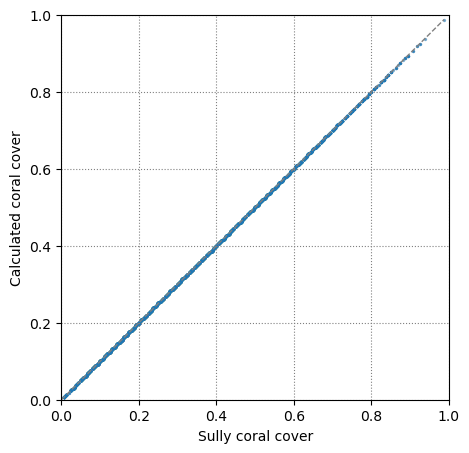

In [23]:
ARCHIVED_REEF_ID_COL = "static_descriptors_reef_id (archived field)"  # unique for each
SULLY_REEF_ID_COL = "Reef_ID_sully"  # however Sully devised theirs

df_for_maps = pd.read_csv(config.sully_og_dir / "data_for_maps.csv")
# Same for df_for_maps — round before converting to float
df_for_maps["Depth"] = pd.to_numeric(df_for_maps["Depth"], errors="coerce").astype(
    "float"
)


def _normalize_name(value: object) -> str:
    if pd.isna(value):
        return ""
    return (
        str(value).lower().replace("`", "").replace("'", "").replace(",", " ").strip()
    )


def _name_match_score(reef_name: str, row: pd.Series) -> int:
    """Score how well a Sully row's place names match substrate reef_name."""
    rn = _normalize_name(reef_name)
    if not rn:
        return 0

    score = 0
    for col in ("City_Town", "City_Town_2", "City_Town_3"):
        val = _normalize_name(row.get(col))
        if not val:
            continue
        if val in rn or rn in val:
            score += 3
        for token in val.split():
            if len(token) > 3 and token in rn:
                score += 1

    # Helpful for house-reef pairs that share City_Town_2 (e.g. Lawaki North/South)
    for hint in ("north", "south", "east", "west"):
        if hint in rn and hint in _normalize_name(
            " ".join(str(row.get(c, "") or "") for c in ("City_Town_2", "City_Town_3"))
        ):
            score += 2

    return score


def resolve_survey_reef_id(group: pd.DataFrame) -> pd.Series:
    """Pick one Sully Reef_ID when (days, depth, cover) matches multiple sites."""
    candidates = group[SULLY_REEF_ID_COL].dropna().unique()
    if len(candidates) == 1:
        row = group.iloc[0]
        return pd.Series(
            {
                SULLY_REEF_ID_COL: candidates[0],
                "sully_site": row["sully_site"],
                "tie_breaker": "unique",
            }
        )

    # 1) archived Reef_ID from Substrate.csv
    archived = group["archived_reef_id"].iloc[0]
    if pd.notna(archived):
        archived_hits = group[group[SULLY_REEF_ID_COL] == archived]
        if len(archived_hits) == 1:
            row = archived_hits.iloc[0]
            return pd.Series(
                {
                    SULLY_REEF_ID_COL: row[SULLY_REEF_ID_COL],
                    "sully_site": row["sully_site"],
                    "tie_breaker": "archived",
                }
            )

    # 2) reef_name vs City_Town fields
    reef_name = group["reef_name"].iloc[0]
    scored = group.copy()
    scored["name_score"] = scored.apply(
        lambda r: _name_match_score(reef_name, r), axis=1
    )
    best_score = scored["name_score"].max()
    if best_score > 0:
        top = scored[scored["name_score"] == best_score]
        if len(top) == 1:
            row = top.iloc[0]
            return pd.Series(
                {
                    SULLY_REEF_ID_COL: row[SULLY_REEF_ID_COL],
                    "sully_site": row["sully_site"],
                    "tie_breaker": "reef_name",
                }
            )

    # 3) fallback — stable choice, flagged for manual review
    row = group.sort_values(SULLY_REEF_ID_COL).iloc[0]
    return pd.Series(
        {
            SULLY_REEF_ID_COL: row[SULLY_REEF_ID_COL],
            "sully_site": row["sully_site"],
            "tie_breaker": "fallback",
        }
    )


# --- 1. Substrate: one row per survey ---
survey_cols = [
    "survey_id",
    "site_id",
    "reef_name",
    "days_since_19811231",
    "Depth",
    "coral_cover",
]
if ARCHIVED_REEF_ID_COL in coral_covers_df.columns:
    survey_cols.append(ARCHIVED_REEF_ID_COL)

survey_df = coral_covers_df[survey_cols].drop_duplicates("survey_id").copy()
survey_df = survey_df.rename(
    columns={ARCHIVED_REEF_ID_COL: "archived_reef_id"}
    if ARCHIVED_REEF_ID_COL in survey_cols
    else {}
)
if "archived_reef_id" not in survey_df.columns:
    survey_df["archived_reef_id"] = pd.NA

# --- 2. Sully: one row per survey record ---
sully_df = df_for_maps[
    [
        "Reef_ID",
        "site",
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
        "City_Town",
        "City_Town_2",
        "City_Town_3",
    ]
].copy()
sully_df["Depth"] = pd.to_numeric(sully_df["Depth"], errors="coerce")
sully_df["days_since_19811231"] = pd.to_numeric(
    sully_df["days_since_19811231"], errors="coerce"
)

# --- 3. Primary match on (date, depth, cover) ---
bridge = survey_df.merge(
    sully_df.rename(columns={"Reef_ID": SULLY_REEF_ID_COL, "site": "sully_site"}),
    left_on=["days_since_19811231", "Depth", "coral_cover"],
    right_on=["days_since_19811231", "Depth", "Average_coral_cover"],
    how="inner",
)

bridge["n_reef_matches"] = bridge.groupby("survey_id")[SULLY_REEF_ID_COL].transform(
    "nunique"
)
ambiguous = bridge[bridge["n_reef_matches"] > 1].copy()

# --- 4. Tie-break ambiguous survey matches ---
survey_matches = (
    bridge.groupby("survey_id", group_keys=False)
    .apply(resolve_survey_reef_id, include_groups=False)
    .reset_index()
)

# --- 5. One row per matched survey (Sully metadata attached) ---
sully_lookup = sully_df.rename(columns={"Reef_ID": SULLY_REEF_ID_COL}).drop_duplicates(
    subset=[
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
    ]
)[
    [
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
        "City_Town",
        "City_Town_2",
        "City_Town_3",
    ]
]

resolved = survey_df.merge(survey_matches, on="survey_id", how="inner")
resolved = resolved.merge(
    sully_lookup,
    left_on=[
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "coral_cover",
    ],
    right_on=[
        SULLY_REEF_ID_COL,
        "days_since_19811231",
        "Depth",
        "Average_coral_cover",
    ],
    how="left",
    validate="m:1",
)

# --- 6. site_id -> canonical Sully Reef_ID (for reuse across surveys) ---
site_bridge = (
    resolved.groupby("site_id")
    .agg(
        Reef_ID=(SULLY_REEF_ID_COL, lambda s: s.mode().iloc[0]),
        sully_site=("sully_site", lambda s: s.mode().iloc[0]),
        n_surveys=("survey_id", "nunique"),
    )
    .reset_index()
)

merged_df = resolved.rename(columns={SULLY_REEF_ID_COL: "Reef_ID"})

# --- diagnostics ---
print(f"Bridge rows (pre-resolution): {len(bridge):,}")
print(f"Ambiguous survey matches: {ambiguous['survey_id'].nunique():,}")
print("Tie-breaker usage:")
print(merged_df["tie_breaker"].value_counts(dropna=False).to_string())
if merged_df["tie_breaker"].eq("fallback").any():
    display(
        merged_df.loc[
            merged_df["tie_breaker"] == "fallback",
            ["survey_id", "site_id", "reef_name", "Reef_ID", "coral_cover"],
        ].head(20)
    )

merged_df["abs_diff"] = (
    merged_df["coral_cover"] - merged_df["Average_coral_cover"]
).abs()
print(
    f"Post-resolution mismatches (>{1 / 160:.5f}): "
    f"{(merged_df['abs_diff'] > 1 / 160 + 1e-9).sum():,}"
)


max_cover = max(
    (np.nanmax(merged_df["Average_coral_cover"])), np.nanmax((merged_df["coral_cover"]))
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged_df["Average_coral_cover"], merged_df["coral_cover"], s=2, alpha=0.5)
ax.plot([0, max_cover], [0, max_cover], color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Sully coral cover")
ax.set_ylabel("Calculated coral cover")
ax.grid("--", color="grey", ls=":")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Sully-esque processing

In [24]:
# rename columns for convenience
coral_covers_df.drop(columns="Depth", inplace=True)
coral_covers_df.rename(columns={"depth (m)": "depth"}, inplace=True)

# remove rows with nan values in vital rows
cols_to_remove_nans = ["latitude", "longitude", "depth", "coral_cover", "date"]

print(f"{len(coral_covers_df)} rows before removing nans")
for col in cols_to_remove_nans:
    num_nans = len(coral_covers_df[coral_covers_df[col].isna()])
    row_str = "row" if num_nans == 1 else "rows"
    print(f"Removed {num_nans} {row_str} with nan values for {col}")
    coral_covers_df = coral_covers_df[coral_covers_df[col].notna()]

print(f"{len(coral_covers_df)} rows after removing nans")


17319 rows before removing nans
Removed 28 rows with nan values for latitude
Removed 2 rows with nan values for longitude
Removed 0 rows with nan values for depth
Removed 0 rows with nan values for coral_cover
Removed 0 rows with nan values for date
17289 rows after removing nans


In [25]:
import geopandas as gpd

cols_to_keep = [
    "site_id",
    "survey_id",
    "latitude",
    "longitude",
    "date",
    "depth",
    "coral_cover",
]
coral_covers_df = coral_covers_df[cols_to_keep]
# make into a geodataframe
coral_covers_df = gpd.GeoDataFrame(
    coral_covers_df,
    geometry=gpd.points_from_xy(coral_covers_df.longitude, coral_covers_df.latitude),
)
coral_covers_df.set_crs("EPSG:4326", inplace=True)

,site_id,survey_id,latitude,longitude,date,depth,coral_cover,geometry
0,6a8719bb-91fe-46c1-9635-37fb1f022ea9,000887f9-b8c4-4c43-bc63-700c0e8b385b,11.015972,119.309306,2016-04-20,3.0,0.625,POINT (119.30931 11.01597)
52,165deb2d-692c-49c9-889d-7ce5c6156657,00103835-7d8a-4099-a58b-bac77e8e81bc,-4.549778,129.955917,2018-12-08,10.0,0.4625,POINT (129.95592 -4.54978)
104,35a4fe9c-76e0-4961-a0eb-0953acf2dc7e,0016ef4b-d18c-4ace-a821-ec622688a708,10.516083,124.669806,2008-07-24,12.0,0.35,POINT (124.66981 10.51608)
156,ba897ac0-d2e4-453c-946c-934f8b9ba838,001a09e0-e52f-4adf-bb2d-e66e2bacb3b5,-16.499417,-151.783972,2014-10-19,7.0,0.4,POINT (-151.78397 -16.49942)
208,9067f611-93bd-4e0b-97cc-94d9b4ec4266,001adbf1-e2eb-4ef7-b600-bd8a923e0020,2.548556,103.960028,2022-08-23,5.2,0.25625,POINT (103.96003 2.54856)
...,...,...,...,...,...,...,...,...
893698,90061ba9-e064-4fae-83e0-23056128e99c,ffe9eeba-1f89-42e8-aab0-b4e2826d39de,-18.159667,178.399667,2008-01-08,5.0,0.30625,POINT (178.39967 -18.15967)
893750,22f8a34a-19f1-4694-9473-fd015c6d9fbe,ffed30dd-92b6-401a-9db3-caf97ac61def,-16.506417,-151.783611,2025-06-03,1.0,0.25,POINT (-151.78361 -16.50642)
893802,149d78f9-cd42-42dd-9f0c-b5211b0d5502,ffed3232-2e27-4a6c-aa48-d092783ab9c3,22.666667,121.463333,1997-07-17,3.0,0.2875,POINT (121.46333 22.66667)
893854,6dea61ac-99ad-4d18-9371-62abda7b9a27,ffee6589-4266-4212-99a9-2d293219d063,15.930000,108.528611,2004-05-24,2.0,0.175,POINT (108.52861 15.93)


In [65]:
# assign ecoregion
from src.processing import processdata

# assign ecoregion info directly to coral_covers_df
coral_covers_df = processdata.assign_points_to_shapes(coral_covers_df, config.meow_dir)

In [ ]:
# turbidity
# closest population
# cyclone exposure
# mpa status
# land habitat type?
# wealth?

# coincidence of bleaching and cover change?

# DEPRECATED

In [ ]:
# def dms_to_reef_id(deg, minute, second, hem):
#     minutes_dec = minute + second / 60
#     whole_m = int(minutes_dec)
#     frac = round((minutes_dec - whole_m) * 100)
#     return f"{deg}.{whole_m}.{frac:02d}{hem}"


# # create Reef_ID column in coral_cover_df
# # for now, remove any rows with nans in the necessary tables (just for checking consistency)
# coord_cols = [
#     "latitude_degrees",
#     "latitude_minutes",
#     "latitude_seconds",
#     "latitude_cardinal_direction",
#     "longitude_degrees",
#     "longitude_minutes",
#     "longitude_seconds",
#     "longitude_cardinal_direction",
# ]
# coral_covers_df = coral_covers_df.dropna(subset=coord_cols).copy()

# # convert longitude_degrees longitude_minutes longitude_seconds(decimal) columns (e.g. 166 23 8.4 E) to to longitude_degrees longitude_minutes longitude_seconds(int) (166.23.14E)
# coral_covers_df["Reef_ID_lons"] = coral_covers_df.apply(
#     lambda row: dms_to_reef_id(
#         row["longitude_degrees"],
#         row["longitude_minutes"],
#         row["longitude_seconds"],
#         row["longitude_cardinal_direction"],
#     ),
#     axis=1,
# )
# coral_covers_df["Reef_ID_lats"] = coral_covers_df.apply(
#     lambda row: dms_to_reef_id(
#         row["latitude_degrees"],
#         row["latitude_minutes"],
#         row["latitude_seconds"],
#         row["latitude_cardinal_direction"],
#     ),
#     axis=1,
# )
# # concatenate the lons and lats
# coral_covers_df["Reef_ID"] = (
#     coral_covers_df["Reef_ID_lons"] + "." + coral_covers_df["Reef_ID_lats"]
# )

# coral_covers_df.loc[:, "days_since_19811231"] = coral_covers_df.apply(
#     lambda row: (row["date"] - pd.Timestamp("1981-12-31")).days, axis=1
# )

# # Ensure numeric conversion, rounding seconds to nearest int before casting
# coral_covers_df["Depth"] = pd.to_numeric(
#     coral_covers_df["depth (m)"], errors="coerce"
# ).astype("float")

# df_for_maps = pd.read_csv(config.sully_og_dir / "data_for_maps.csv")
# # Same for df_for_maps — round before converting to float
# df_for_maps["Depth"] = pd.to_numeric(df_for_maps["Depth"], errors="coerce").astype(
#     "float"
# )


# agg_maps = df_for_maps.groupby(
#     ["Reef_ID", "days_since_19811231", "Depth"], as_index=False
# )["Average_coral_cover"].mean()

# merged_df = coral_covers_df.merge(
#     agg_maps,
#     on=["Reef_ID", "days_since_19811231", "Depth"],
#     how="left",
#     validate="m:1",  # now keys in right dataframe are unique
# )

# max_cover = max(
#     (np.nanmax(merged_df["Average_coral_cover"])), np.nanmax((merged_df["coral_cover"]))
# )

# fig, ax = plt.subplots(figsize=(5, 5))
# ax.scatter(merged_df["Average_coral_cover"], merged_df["coral_cover"], s=2, alpha=0.5)
# ax.plot([0, max_cover], [0, max_cover], color="grey", linestyle="--", linewidth=1)
# ax.set_xlabel("Sully coral cover")
# ax.set_ylabel("Calculated coral cover")
# ax.grid("--", color="grey", ls=":")
# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
